In [2]:
# Data analysis 
import pandas as pd
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
print("Imports successful!")

Imports successful!


In [21]:
# Create an API call to the NOAA NCEI database
ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1'
           '?dataset=daily-summaries'
           '&dataTypes=TOBS'
           '&stations=USC00489902'
           '&startDate=1950-10-01'
           '&endDate=2026-07-15'
           '&units=standard')
ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00489902&startDate=1950-10-01&endDate=2026-07-15&units=standard'

In [22]:
# Open and clean the data
yellowstone_df = pd.read_csv(
    ncei_url,
    na_values=["-99"],
    index_col="DATE",
    parse_dates=["DATE"]
)
yellowstone_df

,STATION,TOBS
DATE,,
2000-11-01,USC00489902,28.0
2000-11-02,USC00489902,22.0
2000-11-03,USC00489902,15.0
2000-11-04,USC00489902,16.0
2000-11-05,USC00489902,NaN
...,...,...
2026-07-08,USC00489902,NaN
2026-07-09,USC00489902,NaN
2026-07-10,USC00489902,NaN


In [24]:
# Keep only the TOBS column
yellowstone_df = yellowstone_df[["TOBS"]]
yellowstone_df.head()
yellowstone_df.tail()

,TOBS
DATE,
2026-07-08,NaN
2026-07-09,NaN
2026-07-10,NaN
2026-07-14,NaN
2026-07-15,NaN


<Axes: title={'center': 'Observed Temperature (F) @ yellowstone East, CO\n1950-2026'}, ylabel='Temperature (F)'>

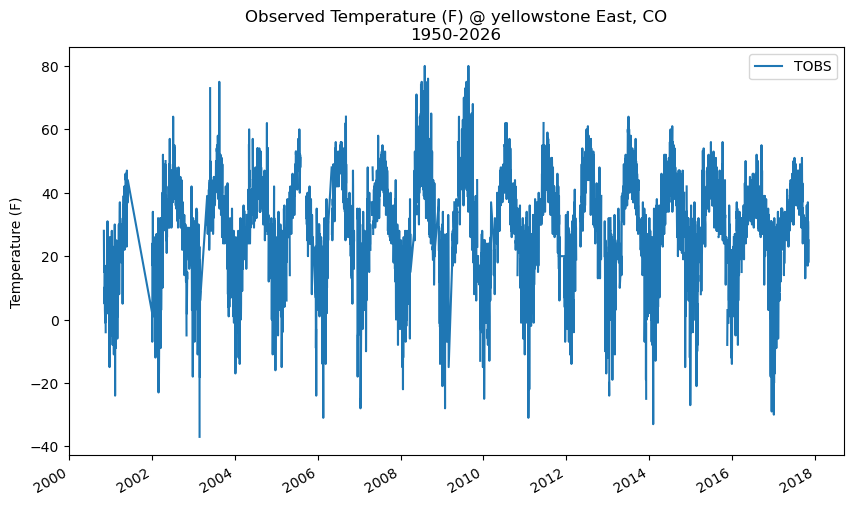

In [25]:
# Plot data with matplotlib
fig, ax = plt.subplots(figsize=(10,6))
yellowstone_df.plot(y='TOBS',
                 ax=ax,
                 ylabel='Temperature (F)',
                 xlabel='',
                 title='Observed Temperature (F) @ yellowstone East, CO\n1950-2026')
# plt.show()

In [26]:
# Take the annual mean of the temperature data
ann_climate_df = yellowstone_df.resample('YE').mean()
ann_climate_df

,TOBS
DATE,
2000-12-31,12.478261
2001-12-31,21.354610
2002-12-31,26.972308
2003-12-31,29.660714
2004-12-31,28.612613
2005-12-31,28.273764
2006-12-31,29.633987
2007-12-31,28.447761
2008-12-31,30.871972


<Axes: xlabel='DATE'>

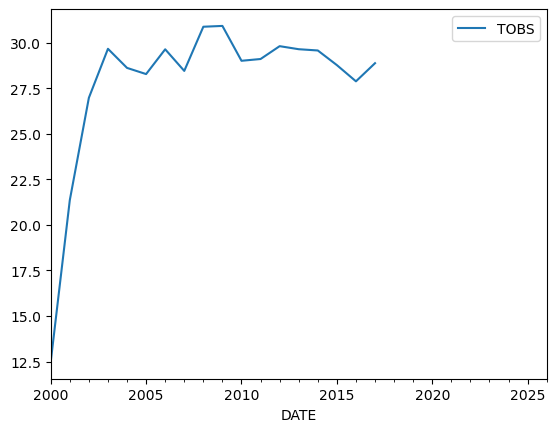

In [27]:
# Plot resampled the data
ann_climate_df.plot()

In [28]:
# Subset the data to look at last 30 years of data
yellowstone_30yr = ann_climate_df.loc["2000":"2025"]
yellowstone_30yr

,TOBS
DATE,
2000-12-31,12.478261
2001-12-31,21.354610
2002-12-31,26.972308
2003-12-31,29.660714
2004-12-31,28.612613
2005-12-31,28.273764
2006-12-31,29.633987
2007-12-31,28.447761
2008-12-31,30.871972


<Axes: xlabel='DATE'>

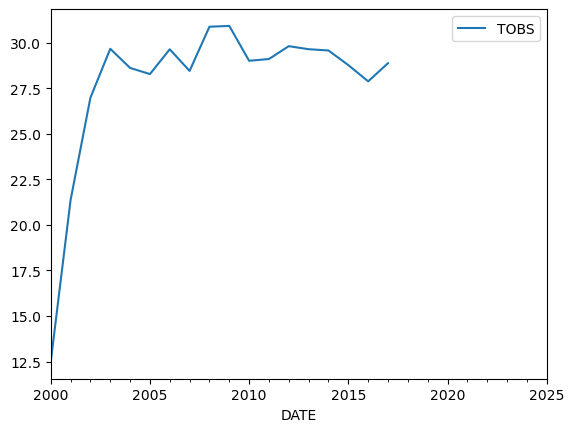

In [29]:
# Plot 30 yrs of data
yellowstone_30yr.plot()

In [30]:
# Create an interactive plot with hvplot
yellowstone_30yr_plot = yellowstone_30yr.hvplot()
yellowstone_30yr_plot

:Curve   [DATE]   (TOBS)

In [31]:
# Save interactive plot as html to host on the web
hv.save(yellowstone_30yr_plot, 'yellowstone.html')